# 0. IMPORT LIBRARY

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from sklearn.cluster import KMeans
from scipy.ndimage import center_of_mass

# PyEIT
import pyeit.mesh as mesh
import pyeit.eit.protocol as protocol
import pyeit.eit.greit as greit
import pyeit.eit.jac as jac
from pyeit.eit.interp2d import sim2pts

# 1. KONFIGURASI DATASET

In [ ]:
savedatapath = "data_mat_files"

datasetno = 2
objectno_baseline = 0   # biasanya phantom homogen / baseline
objectno_target = 2   # phantom dengan objek/anomali

# InjectionSet:
# 1 = adjacent
# 2 = skip1
# 3 = skip2
# 4 = skip3
# 5 = all_against1
# 6 = kombinasi skip1 dan skip3
InjectionSet = 1

USE_ONLY_PART_PART_OF_DATA = True

# 2. FUNGSI PEMILIHAN INJECTION SET

In [93]:
def get_injection_set(injection_set: int):
    if injection_set == 1:
        return np.arange(0, 16), "adjacent"
    elif injection_set == 2:
        return np.arange(16, 32), "skip1"
    elif injection_set == 3:
        return np.arange(32, 48), "skip2"
    elif injection_set == 4:
        return np.arange(48, 64), "skip3"
    elif injection_set == 5:
        return np.arange(64, 79), "all_against1"
    elif injection_set == 6:
        return np.r_[np.arange(16, 32), np.arange(48, 64)], "skip1_skip3"
    else:
        raise ValueError("InjectionSet tidak valid. Gunakan 1 sampai 6.")


UseTheseInj, Injname = get_injection_set(InjectionSet)

print("InjectionSet:", InjectionSet)
print("Injection name:", Injname)
print("UseTheseInj Python index:", UseTheseInj)

InjectionSet: 1
Injection name: adjacent
UseTheseInj Python index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


# 3. LOAD DATA MATLAB

In [96]:
def load_datamat(savedatapath: str, datasetno: int, objectno: int):
    file_with_ext = os.path.join(savedatapath, f"datamat_{datasetno}_{objectno}.mat")
    file_without_ext = os.path.join(savedatapath, f"datamat_1_0.mat")

    if os.path.exists(file_with_ext):
        filepath = file_with_ext
    elif os.path.exists(file_without_ext):
        filepath = file_without_ext
    else:
        raise FileNotFoundError(
            f"File tidak ditemukan:\\n{file_with_ext}\\natau\\n{file_without_ext}"
        )

    data = loadmat(filepath)

    required_keys = ["CurrentPattern", "MeasPattern", "Uel"]
    for key in required_keys:
        if key not in data:
            raise KeyError(f"Variabel '{key}' tidak ditemukan dalam {filepath}")

    return data, filepath


mat0, file0 = load_datamat(savedatapath, datasetno, objectno_baseline)
mat1, file1 = load_datamat(savedatapath, datasetno, objectno_target)

print("Baseline file:", file0)
print("Target file:", file1)

print("\\nKeys baseline:")
print([k for k in mat0.keys() if not k.startswith("__")])

Baseline file: data_mat_files/datamat_1_0.mat
Target file: data_mat_files/datamat_2_2.mat
\nKeys baseline:
['CurrentPattern', 'MeasPattern', 'Uel']


# 4. AMBIL VARIABEL UTAMA

In [97]:
CurrentPattern_all = np.asarray(mat0["CurrentPattern"], dtype=float)
MeasPattern = np.asarray(mat0["MeasPattern"], dtype=float)

U0_all = np.asarray(mat0["Uel"], dtype=float)
U1_all = np.asarray(mat1["Uel"], dtype=float)

print("CurrentPattern_all:", CurrentPattern_all.shape)
print("MeasPattern:", MeasPattern.shape)
print("U0_all:", U0_all.shape)
print("U1_all:", U1_all.shape)

if U0_all.shape != U1_all.shape:
    raise ValueError("Ukuran Uel baseline dan target berbeda.")

CurrentPattern_all: (16, 79)
MeasPattern: (16, 16)
U0_all: (16, 79)
U1_all: (16, 79)


# 5. PILIH BAGIAN DATA SESUAI MATLAB

In [ ]:
if USE_ONLY_PART_PART_OF_DATA:
    CurrentPattern = CurrentPattern_all[:, UseTheseInj]
    U0 = U0_all[:, UseTheseInj]
    U1 = U1_all[:, UseTheseInj]
else:
    CurrentPattern = CurrentPattern_all
    U0 = U0_all
    U1 = U1_all

Ninj = CurrentPattern.shape[1]
Nmeas = U0.shape[0]

# MATLAB Uel(:) = column-major flatten
v0_use = U0.flatten(order="F")
v1_use = U1.flatten(order="F")

print("CurrentPattern selected:", CurrentPattern.shape)
print("U0 selected:", U0.shape)
print("U1 selected:", U1.shape)
print("Ninj:", Ninj)
print("Nmeas:", Nmeas)
print("v0_use:", v0_use.shape)
print("v1_use:", v1_use.shape)
print("Expected length Ninj*Nmeas:", Ninj * Nmeas)

assert len(v0_use) == Ninj * Nmeas
assert len(v1_use) == Ninj * Nmeas

ex_mat shape: (16, 2)
[[ 0  1]
 [ 1  2]
 [ 2  3]
 [ 3  4]
 [ 4  5]
 [ 5  6]
 [ 6  7]
 [ 7  8]
 [ 8  9]
 [ 9 10]
 [10 11]
 [11 12]
 [12 13]
 [13 14]
 [14 15]
 [15  0]]
Jarak elektroda injeksi modulo n_el:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [87]:
# ============================================================
# 7. BUILD meas_mat DARI MeasPattern ASLI
# ============================================================

meas_pairs = pattern_to_pairs(MeasPattern)

print("meas_pairs shape:", meas_pairs.shape)
print(meas_pairs[:10])

# PyEITProtocol membutuhkan meas_mat shape = (n_exc, n_meas, 2)
meas_mat = np.tile(meas_pairs[None, :, :], (Ninj, 1, 1))

# semua measurement dari data MATLAB dipakai
keep_ba = np.ones((Ninj, meas_pairs.shape[0]), dtype=bool)

print("meas_mat:", meas_mat.shape)
print("keep_ba:", keep_ba.shape)

expected_len = meas_mat.shape[0] * meas_mat.shape[1]
print("Expected PyEIT data length:", expected_len)
print("Actual v0_use length:", len(v0_use))

assert expected_len == len(v0_use), (
    f"Mismatch: protokol membutuhkan {expected_len}, "
    f"tetapi v0_use memiliki {len(v0_use)}"
)

meas_pairs shape: (16, 2)
[[ 0  1]
 [ 1  2]
 [ 2  3]
 [ 3  4]
 [ 4  5]
 [ 5  6]
 [ 6  7]
 [ 7  8]
 [ 8  9]
 [ 9 10]]
meas_mat: (16, 16, 2)
keep_ba: (16, 16)
Expected PyEIT data length: 256
Actual v0_use length: 256


In [88]:
# ============================================================
# 8. MESH DAN PROTOKOL PyEIT
# ============================================================

mesh_obj = mesh.create(n_el=n_el, h0=0.05)

protocol_obj = protocol.PyEITProtocol(
    ex_mat=ex_mat,
    meas_mat=meas_mat,
    keep_ba=keep_ba
)

print("Mesh node:", mesh_obj.node.shape)
print("Mesh element:", mesh_obj.element.shape)
print("Protocol ex_mat:", protocol_obj.ex_mat.shape)
print("Protocol meas_mat:", protocol_obj.meas_mat.shape)

Mesh node: (1476, 3)
Mesh element: (2821, 3)
Protocol ex_mat: (16, 2)
Protocol meas_mat: (16, 16, 2)


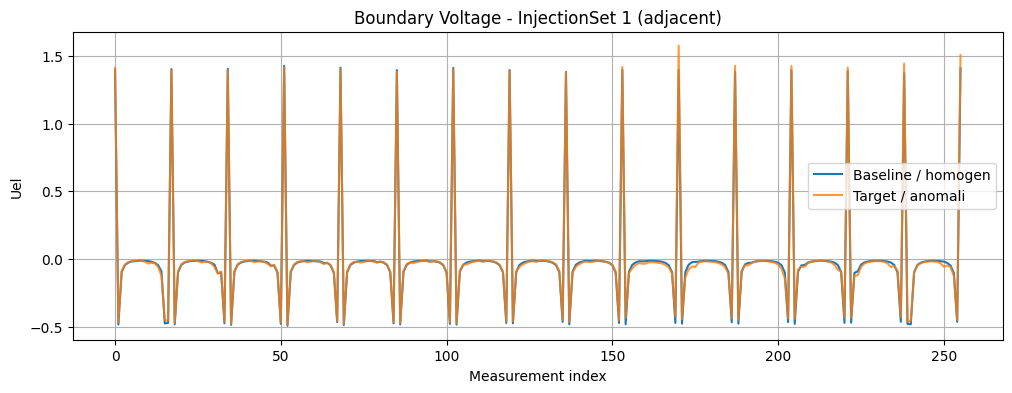

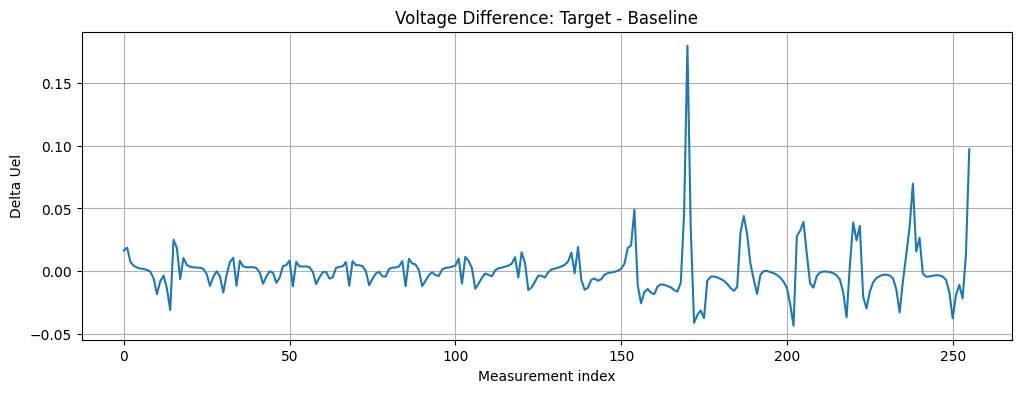

In [89]:
# ============================================================
# 9. VISUALISASI DATA TEGANGAN
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(v0_use, label="Baseline / homogen")
plt.plot(v1_use, label="Target / anomali", alpha=0.8)
plt.title(f"Boundary Voltage - InjectionSet {InjectionSet} ({Injname})")
plt.xlabel("Measurement index")
plt.ylabel("Uel")
plt.legend()
plt.grid(True)
plt.show()

dv = v1_use - v0_use

plt.figure(figsize=(12, 4))
plt.plot(dv)
plt.title("Voltage Difference: Target - Baseline")
plt.xlabel("Measurement index")
plt.ylabel("Delta Uel")
plt.grid(True)
plt.show()

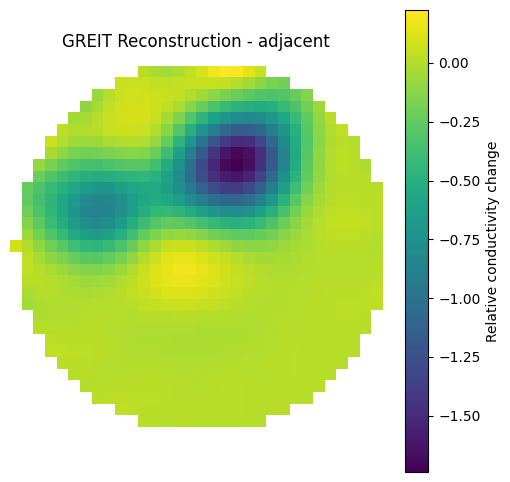

In [90]:
# ============================================================
# 10. GREIT RECONSTRUCTION
# ============================================================

eit_greit = greit.GREIT(mesh_obj, protocol_obj)

eit_greit.setup(
    p=0.30,
    lamb=0.001,
    perm=1,
    jac_normalized=True
)

ds_greit = eit_greit.solve(
    v1_use,
    v0_use,
    normalize=True
)

xg, yg, img_greit = eit_greit.mask_value(
    ds_greit,
    mask_value=np.nan
)

plt.figure(figsize=(6, 6))
plt.imshow(
    np.real(img_greit),
    interpolation="none",
    cmap="viridis"
)
plt.title(f"GREIT Reconstruction - {Injname}")
plt.colorbar(label="Relative conductivity change")
plt.axis("off")
plt.show()

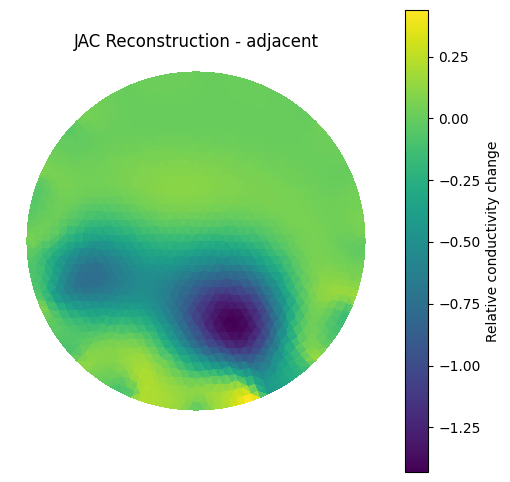

In [91]:
# ============================================================
# 11. JAC RECONSTRUCTION
# ============================================================

eit_jac = jac.JAC(mesh_obj, protocol_obj)

eit_jac.setup(
    p=0.3,
    lamb=0.1,
    method="kotre",
    perm=1,
    jac_normalized=True
)

ds_jac = eit_jac.solve(
    v1_use,
    v0_use,
    normalize=True
)

pts = mesh_obj.node
tri = mesh_obj.element

ds_jac_pts = sim2pts(
    pts,
    tri,
    np.real(ds_jac)
)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.tripcolor(
    pts[:, 0],
    pts[:, 1],
    tri,
    ds_jac_pts,
    shading="flat",
    cmap="viridis"
)

ax.set_aspect("equal")
ax.set_title(f"JAC Reconstruction - {Injname}")
ax.axis("off")
fig.colorbar(im, ax=ax, label="Relative conductivity change")
plt.show()

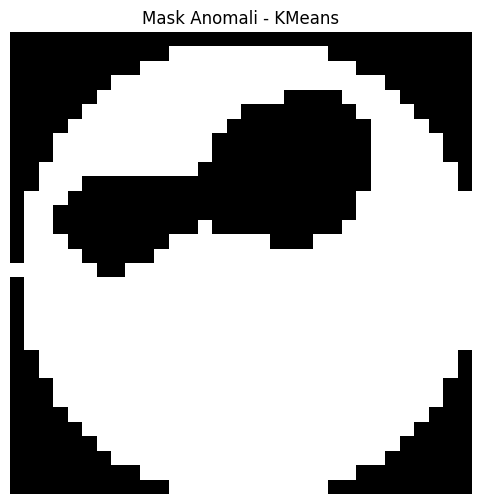

Cluster means: [-0.03424188 -0.83269983]
Cluster anomali: 0


In [92]:
# ============================================================
# 12. K-MEANS SEGMENTASI
# ============================================================

img = np.real(img_greit)
valid_mask = ~np.isnan(img)

values = img[valid_mask].reshape(-1, 1)

kmeans = KMeans(
    n_clusters=2,
    random_state=0,
    n_init=10
)

labels_valid = kmeans.fit_predict(values)

cluster_means = np.array([
    values[labels_valid == i].mean()
    for i in range(2)
])

# Untuk anomali konduktivitas tinggi:
anomali_cluster = int(np.argmax(cluster_means))

# Jika anomali muncul sebagai nilai rendah, pakai ini:
# anomali_cluster = int(np.argmin(cluster_means))

mask_anomali = np.zeros_like(img, dtype=bool)
mask_anomali[valid_mask] = labels_valid == anomali_cluster

plt.figure(figsize=(6, 6))
plt.imshow(mask_anomali, cmap="gray")
plt.title("Mask Anomali - KMeans")
plt.axis("off")
plt.show()

print("Cluster means:", cluster_means)
print("Cluster anomali:", anomali_cluster)